# คำนวณระยะทางจาก Site 12 (Hua Pluak, Sao Hai) ไปถนนมิตรภาพ (Mittraphap Road / Highway 2)

**วัตถุประสงค์:** หาค่าที่ขาดหายไปสำหรับ Table 6 — ระยะทางจาก Site 12 ไปยังเส้นศูนย์กลางถนนมิตรภาพจริง (ดึงจาก OpenStreetMap ด้วย osmnx เหมือนวิธีที่ใช้กับอีก 3 จุด purposive ในต้นฉบับ Section 3.6)

**พิกัด Site 12** (จากไฟล์ gistar_full_results.csv ที่ใช้สร้าง Table 3): lat = 14.636086, lon = 100.8610166

In [5]:
!pip install -q osmnx shapely geopandas

import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import nearest_points

print('พร้อมใช้งาน ✅, osmnx version:', ox.__version__)

พร้อมใช้งาน ✅, osmnx version: 2.1.1


## 1. ดึงเส้นทางถนนมิตรภาพ (Highway 2) จาก OpenStreetMap

ใช้วิธีเดียวกับที่ต้นฉบับระบุไว้ใน Section 3.6/Limitations: ดึง geometry จริงของ Mittraphap Road ด้วย osmnx แทนการประมาณเส้นทางแบบ waypoint

In [6]:
SITE12_LAT = 14.636086
SITE12_LON = 100.8610166

# ดึงถนนสายหลัก (Highway 2 / มิตรภาพ) ในรัศมีรอบ Site 12 และพื้นที่คลอบคลุมจุดอื่นๆ ในแคมเปญ
# ใช้ query แบบ place-based เพื่อให้ครอบคลุมเส้นทางมิตรภาพผ่านสระบุรีทั้งหมด
try:
    roads = ox.features_from_place(
        'Saraburi, Thailand',
        tags={'highway': 'trunk', 'ref': 'AH1'}  # มิตรภาพ = ทางหลวงหมายเลข 2 = Asian Highway 1 ผ่านสระบุรี
    )
    print(f'พบ {len(roads)} segment จาก place query')
except Exception as e:
    print('⚠️ place query ไม่สำเร็จ:', e)
    roads = None

if roads is None or len(roads) == 0:
    print('ลองใช้ bounding-box query รอบ Site 12 แทน (รัศมีกว้างขึ้น)')
    north, south, east, west = 15.2, 14.0, 101.7, 100.5  # ครอบคลุมทุกจุดในแคมเปญ
    roads = ox.features_from_bbox(
        bbox=(west, south, east, north),
        tags={'highway': ['trunk', 'primary'], 'ref': ['AH1', '1', '2']}
    )
    print(f'พบ {len(roads)} segment จาก bbox query')

roads = roads[roads.geometry.type.isin(['LineString', 'MultiLineString'])]
print(f'จำนวน road segment ที่เป็นเส้น (LineString): {len(roads)}')
roads.head()

พบ 161 segment จาก place query
จำนวน road segment ที่เป็นเส้น (LineString): 161


geometry highway  \
element id                                                                    
way     40195478  LINESTRING (100.86295 14.34344, 100.86414 14.3...   trunk   
        40268400  LINESTRING (100.89042 14.54727, 100.88951 14.5...   trunk   
        40268401  LINESTRING (100.88951 14.54633, 100.88896 14.5...   trunk   
        40268402  LINESTRING (100.88937 14.54645, 100.89027 14.5...   trunk   
        40268404  LINESTRING (100.92535 14.5569, 100.92808 14.55...   trunk   

                               name:en  ref maxspeed int_ref lanes  \
element id                                                           
way     40195478    Phahon Yothin Road    1      NaN     AH1     3   
        40268400  Saraburi Bypass Road  362      NaN     NaN   NaN   
        40268401  Saraburi Bypass Road  362      NaN     NaN   NaN   
        40268402  Saraburi Bypass Road  362      NaN     NaN   NaN   
        40268404  Saraburi Bypass Road  362      NaN     NaN     2   

                                   name oneway     source  ... minspeed  \
element id                                                 ...            
way     40195478            ถนนพหลโยธิน    yes  GPS; sign  ...      NaN   
        40268400  ถนนเลี่ยงเมืองสระบุรี    yes        GPS  ...      NaN   
        40268401  ถนนเลี่ยงเมืองสระบุรี    yes  GPS; sign  ...      NaN   
        40268402  ถนนเลี่ยงเมืองสระบุรี    yes        GPS  ...      NaN   
        40268404  ถนนเลี่ยงเมืองสระบุรี    yes   GPS;sign  ...       60   

                 turn:lanes name:th-Latn maxheight lane_markings bicycle foot  \
element id                                                                      
way     40195478        NaN          NaN       NaN           NaN     NaN  NaN   
        40268400        NaN          NaN       NaN           NaN     NaN  NaN   
        40268401        NaN          NaN       NaN           NaN     NaN  NaN   
        40268402        NaN          NaN       NaN           NaN     NaN  NaN   
        40268404        NaN          NaN       NaN           NaN     NaN  NaN   

                 horse turn:lanes:backward turn:lanes:forward  
element id                                                     
way     40195478   NaN                 NaN                NaN  
        40268400   NaN                 NaN                NaN  
        40268401   NaN                 NaN                NaN  
        40268402   NaN                 NaN                NaN  
        40268404   NaN                 NaN                NaN  

[5 rows x 30 columns]

## 2. คำนวณระยะทางจาก Site 12 ไปยังเส้นถนนที่ใกล้ที่สุด

แปลงเป็น UTM (EPSG:32647) ก่อนคำนวณระยะทางเป็นเมตร/กิโลเมตรจริง (ตรงตาม methodology ที่ใช้ทั้งฉบับ)

In [7]:
site12_point = gpd.GeoDataFrame(
    {'name': ['Site 12']}, geometry=[Point(SITE12_LON, SITE12_LAT)], crs='EPSG:4326'
).to_crs('EPSG:32647')

roads_utm = roads.to_crs('EPSG:32647')
road_union = roads_utm.geometry.union_all() if hasattr(roads_utm.geometry, 'union_all') else roads_utm.unary_union

site12_geom = site12_point.geometry.iloc[0]
nearest_on_road = nearest_points(site12_geom, road_union)[1]
distance_m = site12_geom.distance(nearest_on_road)
distance_km = distance_m / 1000

print(f'ระยะทางจาก Site 12 ไปถนนมิตรภาพที่ใกล้ที่สุด: {distance_km:.2f} กม.')

ระยะทางจาก Site 12 ไปถนนมิตรภาพที่ใกล้ที่สุด: 2.81 กม.


## 3. ตรวจสอบด้วยแผนที่ (ภาพ) ก่อนนำไปใช้จริง

⚠️ **สำคัญ:** ดูรูปแล้วยืนยันว่าเส้นสีแดงที่ขึ้นมาคือถนนมิตรภาพจริง ไม่ใช่ถนนสายอื่นที่ osmnx ดึงมาผิดตัว ก่อนนำค่าระยะทางไปใส่ใน Table 6

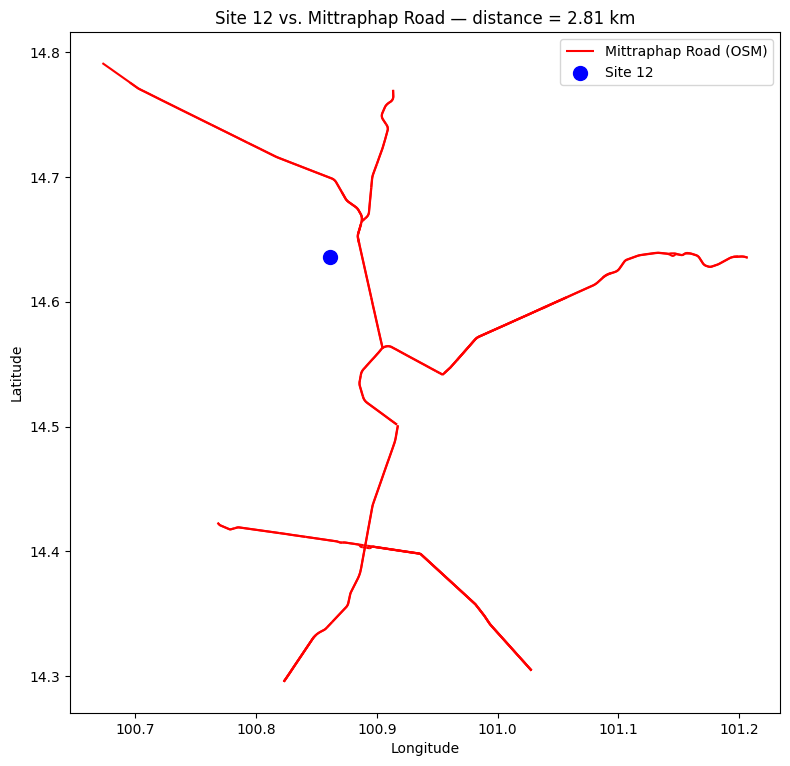

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
roads.plot(ax=ax, color='red', linewidth=1.5, label='Mittraphap Road (OSM)')
ax.scatter([SITE12_LON], [SITE12_LAT], color='blue', s=100, zorder=5, label='Site 12')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Site 12 vs. Mittraphap Road — distance = {distance_km:.2f} km')
ax.legend()
plt.tight_layout()
plt.savefig('site12_road_check.png', dpi=150)
plt.show()

---
✅ **นำค่า `distance_km` ที่ได้ (ถ้าตรวจแผนที่แล้วถูกต้อง) กลับมาบอก Claude ในแชท** เพื่อใส่แทน placeholder สีเหลืองใน Table 6 และคำนวณค่าเฉลี่ยกลุ่มใหม่ทั้งสองกลุ่ม (Significant Gi* hotspots n=4, All other sites n=28)